# Data Cleaning and Exploratory Data Analysis

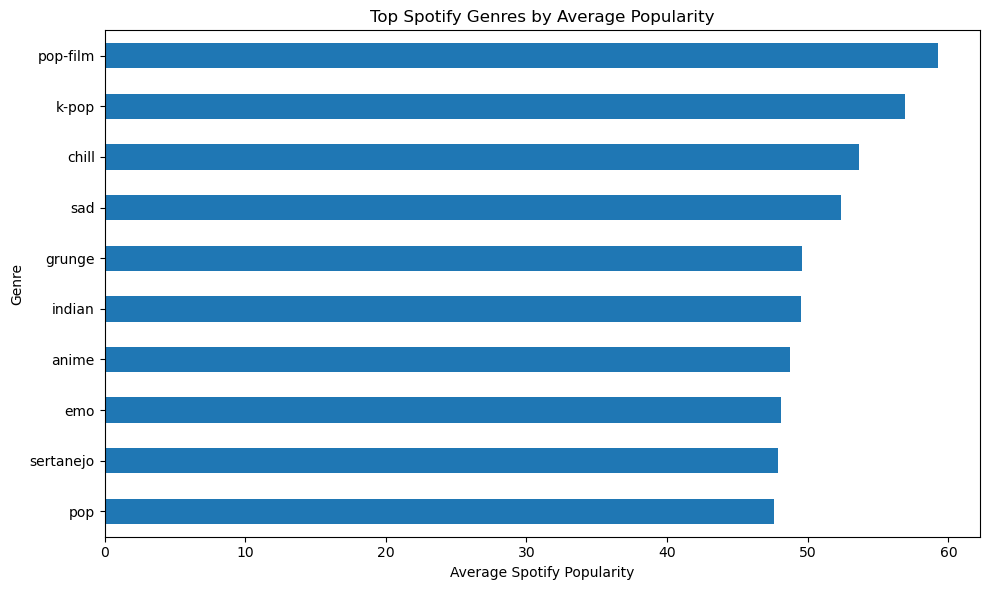

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

spotify = pd.read_csv("../data/spotify_tracks.csv")   

genre_pop = (
    spotify.groupby("track_genre")["popularity"]
           .mean()
           .sort_values(ascending=False)
)

top_n = 10
genre_pop_top = genre_pop.head(top_n)

plt.figure(figsize=(10, 6))
genre_pop_top[::-1].plot(kind="barh")
plt.xlabel("Average Spotify Popularity")
plt.ylabel("Genre")
plt.title("Top Spotify Genres by Average Popularity")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

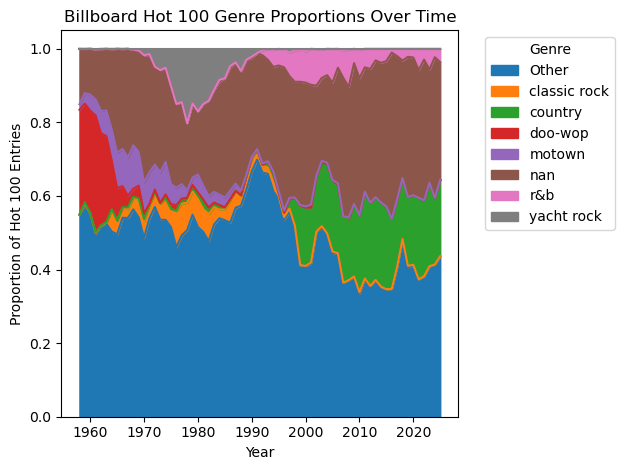

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

hot100g = pd.read_csv("../data/hot100_with_spotify_genres.csv")  

hot100g["chart_date"] = pd.to_datetime(hot100g["chart_date"])
hot100g["year"] = hot100g["chart_date"].dt.year

hot100g["genre_primary"] = (
    hot100g["genre_join"]
    .astype(str)
    .str.split(";")
    .str[0]
    .str.strip()
)

top_genres = hot100g["genre_primary"].value_counts().head(7).index
hot100g["genre_group"] = hot100g["genre_primary"].where(
    hot100g["genre_primary"].isin(top_genres),
    "Other"
)

genre_year_counts = (
    hot100g.groupby(["year", "genre_group"])
           .size()
           .reset_index(name="count")
)

total_per_year = (
    genre_year_counts.groupby("year")["count"]
                     .sum()
                     .rename("total")
                     .reset_index()
)

genre_year_counts = genre_year_counts.merge(total_per_year, on="year")
genre_year_counts["prop"] = genre_year_counts["count"] / genre_year_counts["total"]

genre_year_pivot = (
    genre_year_counts
    .pivot(index="year", columns="genre_group", values="prop")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(12, 6))
genre_year_pivot.plot(kind="area", stacked=True)
plt.ylabel("Proportion of Hot 100 Entries")
plt.xlabel("Year")
plt.title("Billboard Hot 100 Genre Proportions Over Time")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

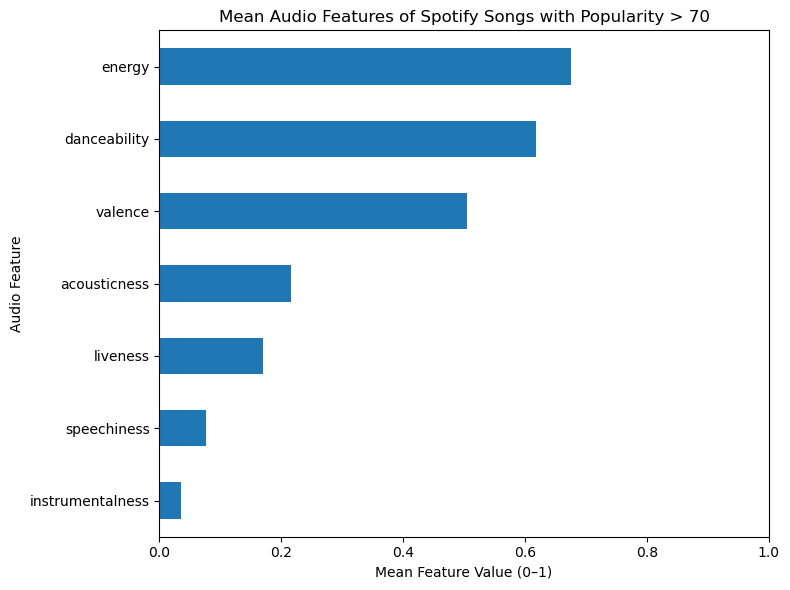

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

spotify = pd.read_csv("../data/spotify_tracks.csv")  

popular_threshold = 70
popular_songs = spotify[spotify["popularity"] > popular_threshold]

audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

popular_means = popular_songs[audio_features].mean().sort_values()

plt.figure(figsize=(8, 6))
popular_means.plot(kind="barh")
plt.xlabel("Mean Feature Value (0–1)")
plt.ylabel("Audio Feature")
plt.title(f"Mean Audio Features of Spotify Songs with Popularity > {popular_threshold}")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()